# Notebook 01 — Analisis Exploratorio de Datos (EDA)

Antes de entrenar ningun modelo, exploro el dataset para entender
que tengo entre manos. El **EDA** (Exploratory Data Analysis) es el paso
mas importante del proyecto: si no entiendo los datos, el modelo tampoco los entendera.

**Lo que hago aqui:**
- Cargo el dataset raw de Spotify y veo su estructura
- Analizo la variable objetivo (popularidad)
- Estudio las correlaciones entre features y popularidad
- Identifico duplicados, nulos y anomalias
- Visualizo el desbalanceo de clases
- Saco conclusiones que guian el preprocesamiento del notebook 02


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10
})
RED, GRAY, BLUE = '#ff2a36', '#cccccc', '#2980b9'

import os
os.makedirs('resources/img', exist_ok=True)
print('Librerias cargadas.')

Librerias cargadas.


## I. Carga del dataset

Cargo el archivo CSV con los datos de Spotify.
Un **CSV** (Comma-Separated Values) es un archivo de texto donde cada fila es
una cancion y cada columna una caracteristica. Es el formato de datos mas comun en ciencia de datos.


In [2]:
df = pd.read_csv('/Users/andoni/Documents/DS BOOTCAMP/Data Science/ONLINE_DS_THEBRIDGE_Andoni/Módulo 3/Proyecto ML /sound-dna/src/data/raw/spotify_tracks.csv')

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'\nColumnas disponibles:')
for col in df.columns:
    print(f'  {col}: {df[col].dtype}')

Filas:    114,000
Columnas: 21

Columnas disponibles:
  Unnamed: 0: int64
  track_id: str
  artists: str
  album_name: str
  track_name: str
  popularity: int64
  duration_ms: int64
  explicit: bool
  danceability: float64
  energy: float64
  key: int64
  loudness: float64
  mode: int64
  speechiness: float64
  acousticness: float64
  instrumentalness: float64
  liveness: float64
  valence: float64
  tempo: float64
  time_signature: int64
  track_genre: str


## II. Primeras filas y estructura

Veo las primeras filas para entender que contiene cada columna.


In [3]:
df.head(3)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [4]:
# Estadisticas descriptivas de las columnas numericas
# mean = media, std = desviacion tipica, min/max = extremos
df.describe().round(3)

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,56999.50,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,32909.11,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.00,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,28499.75,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,56999.50,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,85499.25,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.084,0.598,0.049,0.273,0.683,140.071,4.000
max,113999.00,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


## III. Valores nulos

Un **valor nulo** (NaN) es una celda vacia — no se recoge el dato.
Los modelos de machine learning no pueden trabajar con nulos,
asi que tengo que saber cuantos hay antes de continuar.


In [5]:
nulos = df.isnull().sum()
nulos_total = nulos.sum()
print(f'Total de valores nulos: {nulos_total}')
print()
print(nulos[nulos > 0] if nulos_total > 0 else 'Ningun valor nulo encontrado.')

Total de valores nulos: 3

artists       1
album_name    1
track_name    1
dtype: int64


## IV. Distribucion de la variable objetivo: Popularidad

La **variable objetivo** es lo que quiero predecir: la popularidad (0-100).
Antes de hacer nada, necesito entender como se distribuye.

Una **distribucion** muestra cuantas canciones tienen cada valor de popularidad.
Si la mayoria tienen popularidad baja y pocas tienen popularidad alta,
eso es una distribucion asimetrica con cola larga.


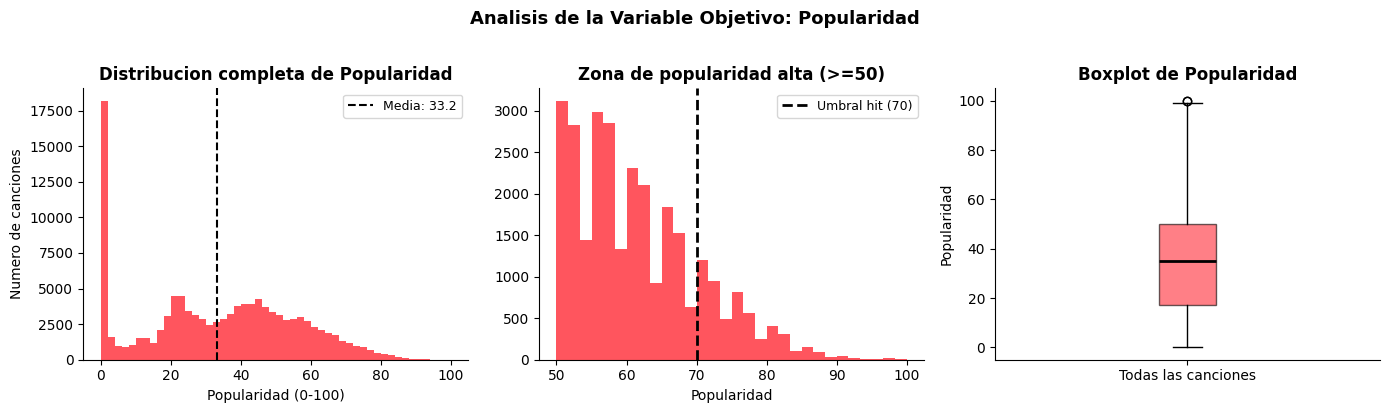

Media:    33.2
Mediana:  35.0
Con pop=0: 16,020 canciones (14.1%)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histograma completo
axes[0].hist(df['popularity'], bins=50, color=RED, alpha=0.8, edgecolor='none')
axes[0].set_xlabel('Popularidad (0-100)')
axes[0].set_ylabel('Numero de canciones')
axes[0].set_title('Distribucion completa de Popularidad', fontweight='bold')
axes[0].axvline(df['popularity'].mean(), color='black', lw=1.5, linestyle='--',
                label=f'Media: {df["popularity"].mean():.1f}')
axes[0].legend(fontsize=9)

# Zoom en la zona de hits (>= 50)
df_hits_zone = df[df['popularity'] >= 50]
axes[1].hist(df_hits_zone['popularity'], bins=30, color=RED, alpha=0.8, edgecolor='none')
axes[1].axvline(70, color='black', lw=2, linestyle='--', label='Umbral hit (70)')
axes[1].set_xlabel('Popularidad')
axes[1].set_title('Zona de popularidad alta (>=50)', fontweight='bold')
axes[1].legend(fontsize=9)

# Boxplot
axes[2].boxplot(df['popularity'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=RED, alpha=0.6),
                medianprops=dict(color='black', lw=2))
axes[2].set_ylabel('Popularidad')
axes[2].set_title('Boxplot de Popularidad', fontweight='bold')
axes[2].set_xticklabels(['Todas las canciones'])

plt.suptitle('Analisis de la Variable Objetivo: Popularidad', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('resources/img/eda_popularidad.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Media:    {df["popularity"].mean():.1f}')
print(f'Mediana:  {df["popularity"].median():.1f}')
print(f'Con pop=0: {(df["popularity"]==0).sum():,} canciones ({(df["popularity"]==0).mean()*100:.1f}%)')

## V. Desbalanceo de clases — Hits vs No-Hits

Defino un **hit** como una cancion con popularidad >= 70.
Este umbral representa el top de lo mas escuchado en Spotify.

El **desbalanceo de clases** ocurre cuando una categoria es mucho mas frecuente que otra.
En nuestro caso: si el 95% de canciones no son hits, un modelo que diga
'no es hit' siempre tendria 95% de accuracy pero seria completamente inutil.
Por eso necesito metricas especiales (F1, AUC) en vez de accuracy.


Total canciones: 114,000
Hits (pop>=70):  5,472 (4.8%)
No hits:         108,528 (95.2%)


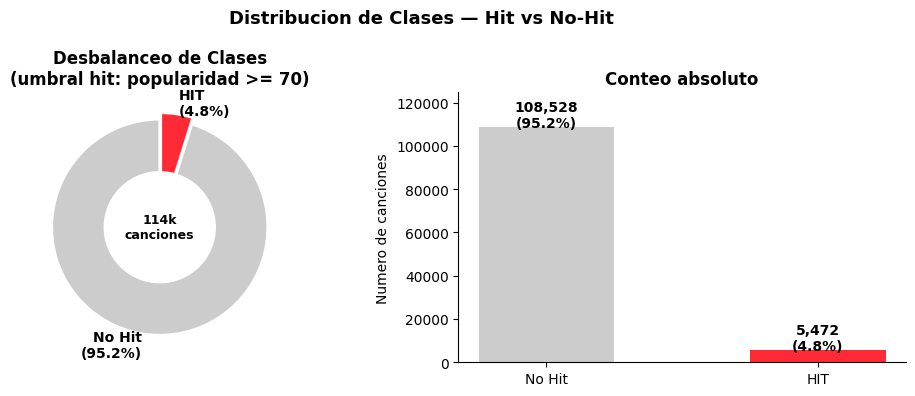

In [7]:
HIT_THRESHOLD = 70
df['is_hit'] = (df['popularity'] >= HIT_THRESHOLD).astype(int)

n_hits    = df['is_hit'].sum()
n_no_hits = len(df) - n_hits
pct_hits  = n_hits / len(df) * 100

print(f'Total canciones: {len(df):,}')
print(f'Hits (pop>=70):  {n_hits:,} ({pct_hits:.1f}%)')
print(f'No hits:         {n_no_hits:,} ({100-pct_hits:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Donut chart
wedges, texts, autotexts = ax1.pie(
    [n_no_hits, n_hits],
    labels=[f'No Hit\n({100-pct_hits:.1f}%)', f'HIT\n({pct_hits:.1f}%)'],
    colors=[GRAY, RED], explode=(0, 0.06), startangle=90,
    autopct='', wedgeprops=dict(lw=2, edgecolor='white'),
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
centre = plt.Circle((0,0), 0.52, fc='white')
ax1.add_patch(centre)
ax1.text(0, 0, f'{len(df)//1000}k\ncanciones', ha='center', va='center', fontsize=9, fontweight='bold')
ax1.set_title(f'Desbalanceo de Clases\n(umbral hit: popularidad >= {HIT_THRESHOLD})', fontweight='bold')

# Barra comparativa
categorias = ['No Hit', 'HIT']
valores = [n_no_hits, n_hits]
colors_bar = [GRAY, RED]
bars = ax2.bar(categorias, valores, color=colors_bar, edgecolor='none', width=0.5)
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x()+bar.get_width()/2, val+200, f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Numero de canciones')
ax2.set_title('Conteo absoluto', fontweight='bold')
ax2.set_ylim(0, max(valores) * 1.15)

plt.suptitle(f'Distribucion de Clases — Hit vs No-Hit', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('resources/img/eda_desbalanceo.png', dpi=150, bbox_inches='tight')
plt.show()

## VI. Correlaciones con la Popularidad

La **correlacion** mide la relacion lineal entre dos variables.
Va de -1 (relacion perfecta inversa) a +1 (relacion perfecta directa).
0 significa que no hay relacion lineal.

Si las correlaciones con popularidad son todas cercanas a 0,
eso indica que la relacion es **no lineal** — necesitamos modelos mas sofisticados
que una simple regresion lineal.


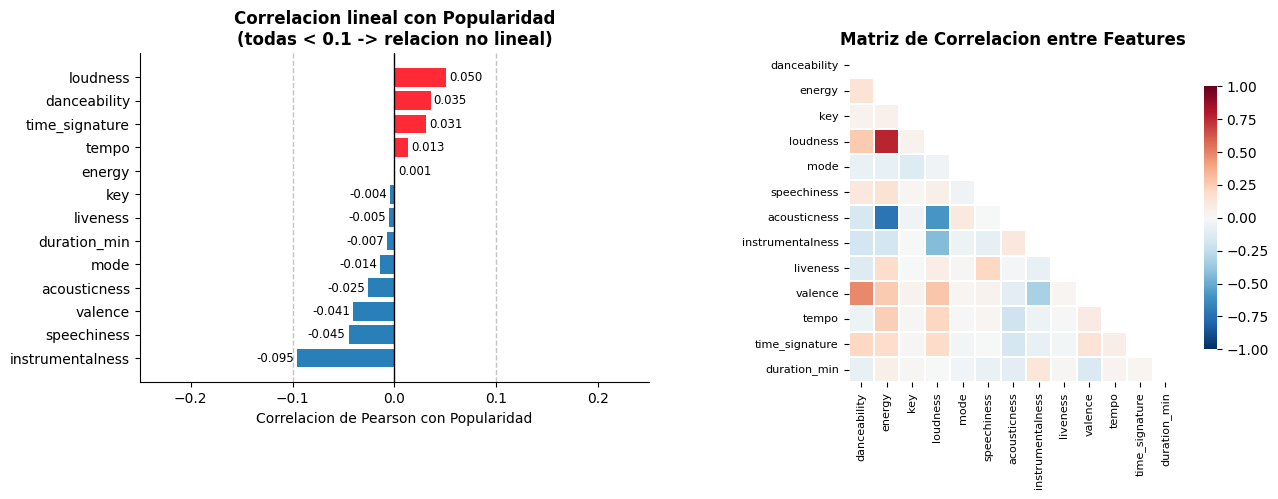

Las correlaciones con popularidad son todas entre -0.1 y +0.1.
Esto confirma que la relacion es no lineal -> necesitamos Random Forest, no regresion lineal.


In [8]:
AUDIO_FEATURES = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature', 'duration_min'
]

# Aseguro que duration_min existe; si no, la creo
if 'duration_min' not in df.columns and 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000

features_disponibles = [f for f in AUDIO_FEATURES if f in df.columns]
corrs = df[features_disponibles + ['popularity']].corr()['popularity'].drop('popularity').sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Barras de correlacion
clrs = [RED if v > 0 else BLUE for v in corrs.values]
bars = ax1.barh(corrs.index, corrs.values, color=clrs, edgecolor='none')
ax1.axvline(0, color='black', lw=1)
ax1.axvline(0.1, color='#888', lw=1, linestyle='--', alpha=0.5)
ax1.axvline(-0.1, color='#888', lw=1, linestyle='--', alpha=0.5)
for bar, val in zip(bars, corrs.values):
    ax1.text(val + (0.003 if val >= 0 else -0.003), bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8.5)
ax1.set_xlabel('Correlacion de Pearson con Popularidad')
ax1.set_title('Correlacion lineal con Popularidad\n(todas < 0.1 -> relacion no lineal)', fontweight='bold')
ax1.set_xlim(-0.25, 0.25)

# Heatmap
corr_matrix = df[features_disponibles].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            ax=ax2, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.8}, annot=False, vmin=-1, vmax=1)
ax2.set_title('Matriz de Correlacion entre Features', fontweight='bold')
ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('resources/img/eda_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('Las correlaciones con popularidad son todas entre -0.1 y +0.1.')
print('Esto confirma que la relacion es no lineal -> necesitamos Random Forest, no regresion lineal.')

## VII. Distribucion de las features de audio

Visualizo como se distribuye cada caracteristica de audio en el dataset.
Esto me ayuda a detectar valores extremos y entender el rango de cada variable.


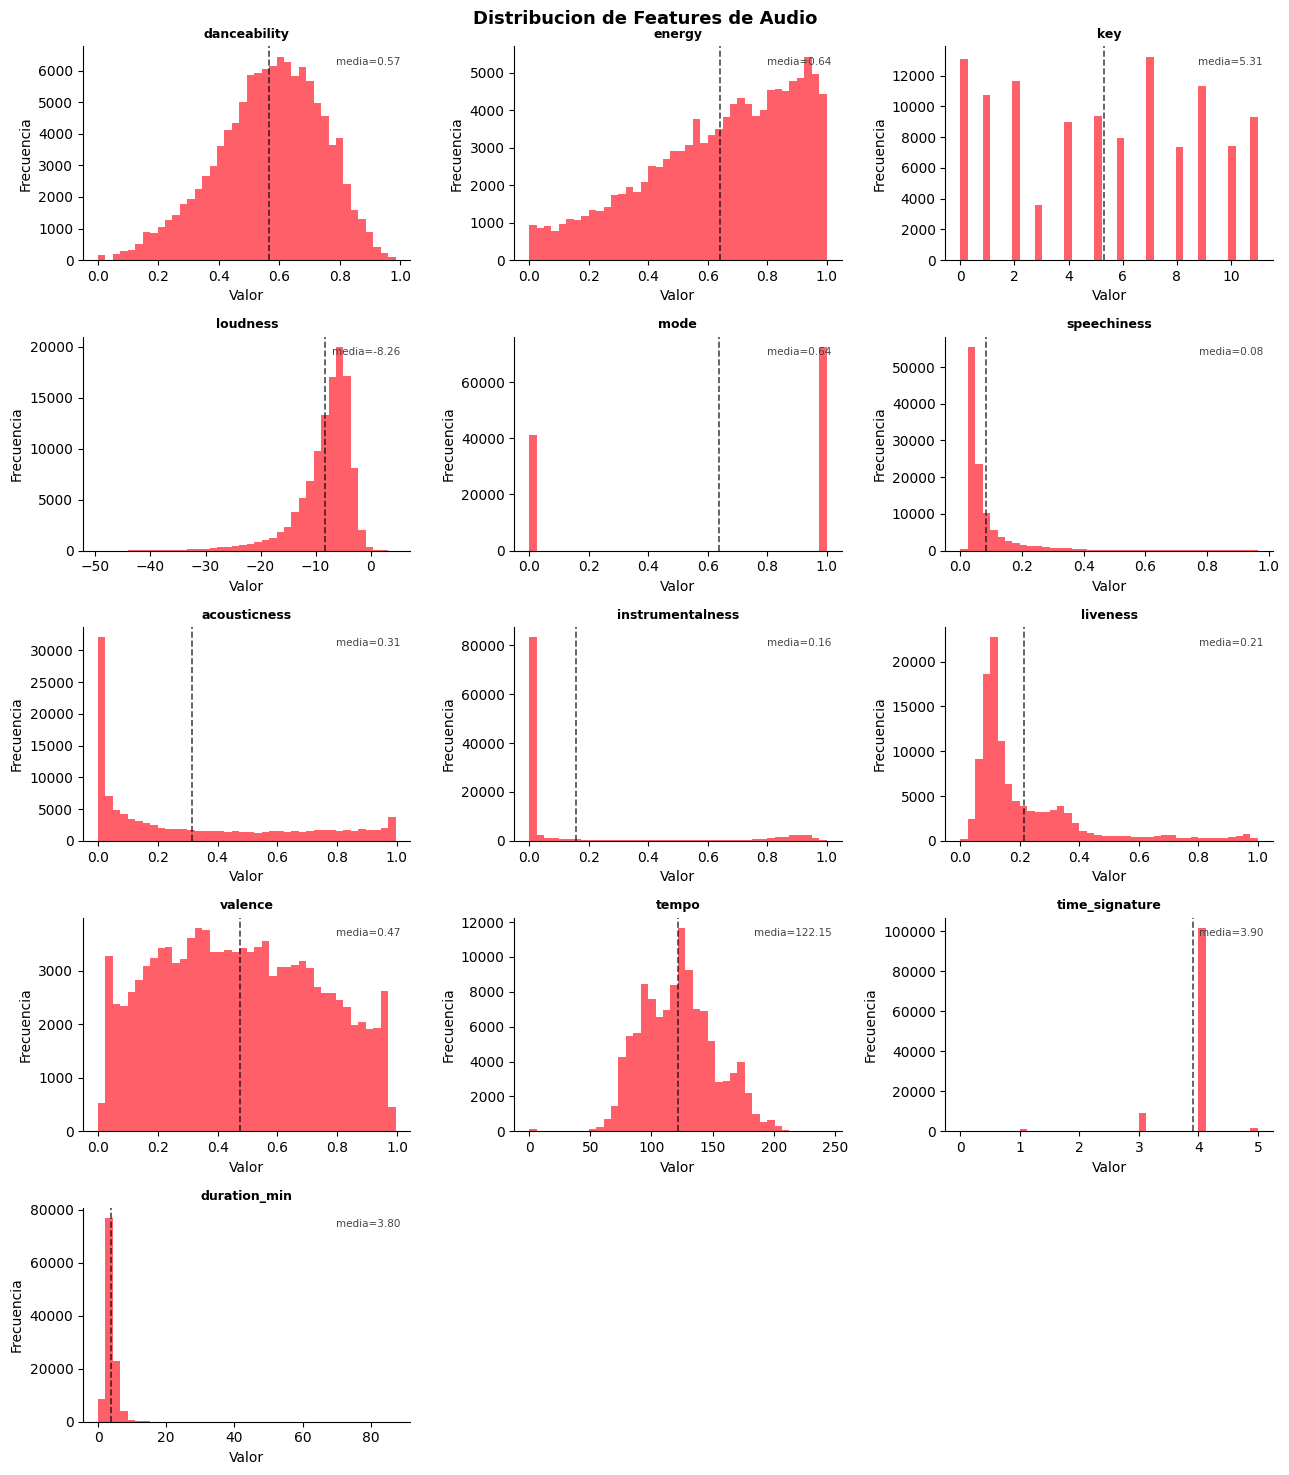

In [9]:
n_features = len(features_disponibles)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features_disponibles):
    axes[i].hist(df[feat].dropna(), bins=40, color=RED, alpha=0.75, edgecolor='none')
    axes[i].set_title(feat, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    media = df[feat].mean()
    axes[i].axvline(media, color='black', lw=1.2, linestyle='--', alpha=0.7)
    axes[i].text(0.97, 0.95, f'media={media:.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=7.5, color='#444')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucion de Features de Audio', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('resources/img/eda_distribuciones_features.png', dpi=150, bbox_inches='tight')
plt.show()

## VIII. Analisis de duplicados

Una cancion puede estar en varios generos a la vez en el dataset.
Eso genera **duplicados por track_id**: la misma cancion con la misma popularidad
pero etiquetada en distintos generos.

Si los dejo, el modelo veria la misma cancion varias veces en entrenamiento
y posiblemente en test tambien, inflando artificialmente las metricas.


Filas totales:         114,000
Canciones unicas:      89,741
Duplicados detectados: 24,259 (21.3%)


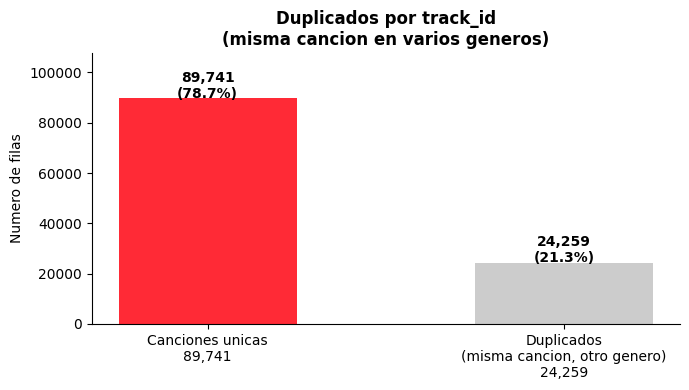

In [10]:
n_total    = len(df)
n_unicos   = df['track_id'].nunique() if 'track_id' in df.columns else len(df)
n_dup      = n_total - n_unicos

print(f'Filas totales:         {n_total:,}')
print(f'Canciones unicas:      {n_unicos:,}')
print(f'Duplicados detectados: {n_dup:,} ({n_dup/n_total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
vals = [n_unicos, n_dup]
labels = [f'Canciones unicas\n{n_unicos:,}', f'Duplicados\n(misma cancion, otro genero)\n{n_dup:,}']
clrs_d = [RED, GRAY]
bars = ax.bar(labels, vals, color=clrs_d, edgecolor='none', width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+200, f'{val:,}\n({val/n_total*100:.1f}%)',
             ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Numero de filas')
ax.set_title('Duplicados por track_id\n(misma cancion en varios generos)', fontweight='bold')
ax.set_ylim(0, max(vals) * 1.2)
plt.tight_layout()
plt.savefig('resources/img/eda_duplicados.png', dpi=150, bbox_inches='tight')
plt.show()

## IX. Distribucion por genero

El dataset tiene 114 generos con exactamente 1000 canciones cada uno.
Esta distribucion perfectamente balanceada por genero es una caracteristica
importante del dataset — no hay sesgo hacia ningun genero en particular.


Generos distintos: 114
Canciones por genero: min=1000, max=1000, media=1000


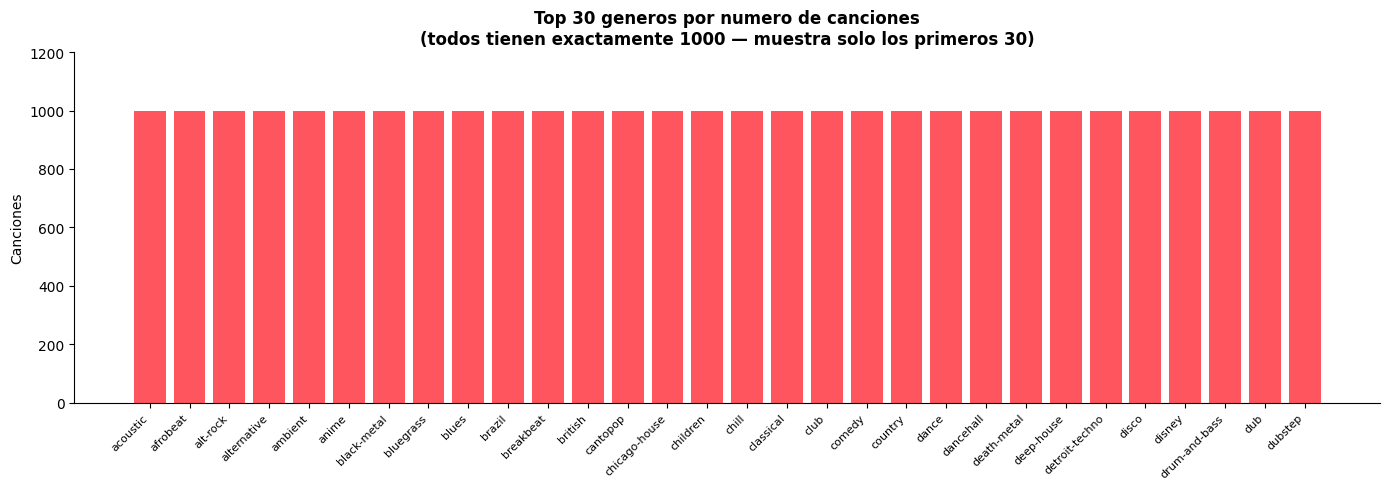

In [11]:
if 'track_genre' in df.columns:
    generos = df['track_genre'].value_counts()
    print(f'Generos distintos: {len(generos)}')
    print(f'Canciones por genero: min={generos.min()}, max={generos.max()}, media={generos.mean():.0f}')
    
    fig, ax = plt.subplots(figsize=(14, 5))
    top_generos = generos.head(30)
    ax.bar(range(len(top_generos)), top_generos.values, color=RED, alpha=0.8, edgecolor='none')
    ax.set_xticks(range(len(top_generos)))
    ax.set_xticklabels(top_generos.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Canciones')
    ax.set_title('Top 30 generos por numero de canciones\n(todos tienen exactamente 1000 — muestra solo los primeros 30)', fontweight='bold')
    ax.set_ylim(0, 1200)
    plt.tight_layout()
    plt.savefig('resources/img/eda_generos.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Columna track_genre no encontrada.')

## X. Popularidad por genero — Top y Bottom

Aunque todos los generos tienen 1000 canciones, la popularidad media
puede variar mucho entre ellos. Esto es informacion relevante para futuros
modelos por genero (trabajo futuro del proyecto).


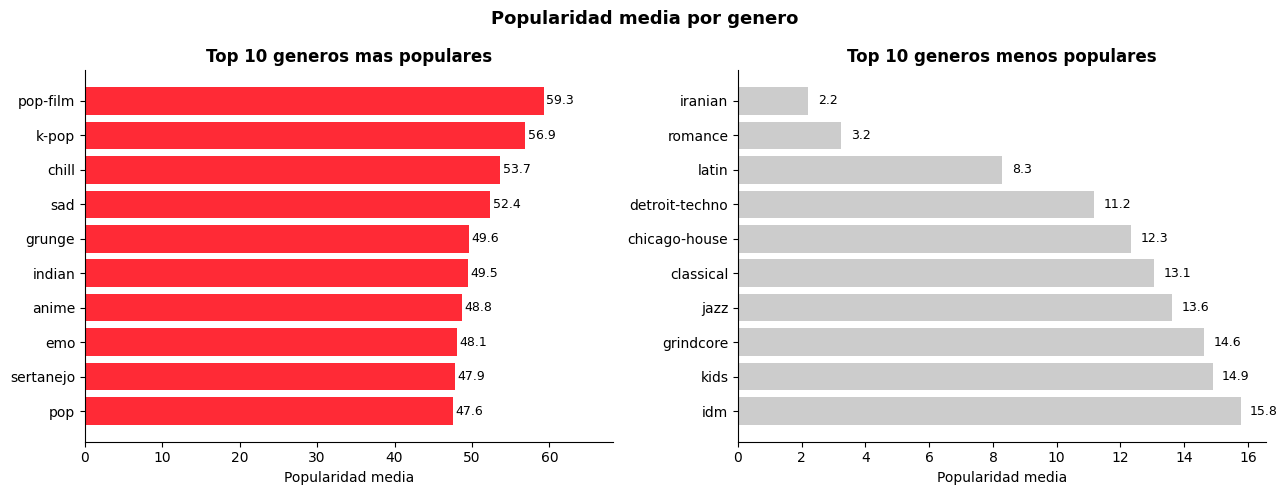

In [12]:
if 'track_genre' in df.columns:
    pop_por_genero = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    
    top10 = pop_por_genero.head(10)
    ax1.barh(top10.index[::-1], top10.values[::-1], color=RED, edgecolor='none')
    for i, (idx, val) in enumerate(zip(top10.index[::-1], top10.values[::-1])):
        ax1.text(val+0.3, i, f'{val:.1f}', va='center', fontsize=9)
    ax1.set_xlabel('Popularidad media')
    ax1.set_title('Top 10 generos mas populares', fontweight='bold')
    ax1.set_xlim(0, pop_por_genero.max() * 1.15)
    
    bot10 = pop_por_genero.tail(10)
    ax2.barh(bot10.index, bot10.values, color=GRAY, edgecolor='none')
    for i, (idx, val) in enumerate(zip(bot10.index, bot10.values)):
        ax2.text(val+0.3, i, f'{val:.1f}', va='center', fontsize=9)
    ax2.set_xlabel('Popularidad media')
    ax2.set_title('Top 10 generos menos populares', fontweight='bold')
    
    plt.suptitle('Popularidad media por genero', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('resources/img/eda_popularidad_genero.png', dpi=150, bbox_inches='tight')
    plt.show()

## XI. Conclusiones del EDA

Este analisis me dio los hallazgos que guian todo el proyecto:

**1. Distribucion asimetrica con cola larga:**
La mayoria de canciones tienen popularidad baja o 0. Los hits son raros.

**2. Desbalanceo severo de clases:**
Solo el 4.8% son hits (popularidad >= 70). Esto obliga a usar F1 y AUC en vez de accuracy.

**3. Correlaciones lineales cercanas a cero:**
Ninguna feature de audio tiene correlacion > 0.1 con popularidad. La relacion es no lineal.
Esto significa que la Regresion Lineal fallara — necesito Random Forest o Gradient Boosting.

**4. Duplicados por track_id:**
Hay ~24.000 canciones repetidas (misma cancion en varios generos).
Hay que eliminarlos antes de hacer el split para no contaminar las metricas.

**5. Dataset perfectamente balanceado por genero:**
114 generos x 1000 canciones = 114.000 filas. Limpio y sin sesgo de muestreo.

**6. Sin valores nulos significativos:**
Solo 3 nulos en todo el dataset. No hay que imputar valores.

**Implicaciones para el preprocesamiento (notebook 02):**
- Eliminar duplicados por track_id
- Filtrar canciones con popularidad < 10 (canciones fantasma)
- Convertir duration_ms a duration_min
- Crear variable is_hit
- Train/test split con stratify=y (para mantener la proporcion de hits)
